In [6]:
%pip install -qU langchain-groq

Note: you may need to restart the kernel to use updated packages.


In [5]:
from langchain_groq import ChatGroq

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    groq_api_key = GROQ_API_KEY,
    model="llama-3.3-70b-versatile",
    temperature=0,
#     max_tokens=None,
#     reasoning_format="parsed",
#     timeout=None,
#     max_retries=2,
    # other params...
)

response = llm.invoke("The first world war between?")
print(response.content)

The First World War, also known as World War I, was fought between the Allied Powers and the Central Powers from 1914 to 1918. The main countries involved were:

**Allied Powers:**

1. France
2. United Kingdom (including Britain, Canada, Australia, and New Zealand)
3. Russia (until 1917)
4. United States
5. Italy (from 1915)
6. Belgium
7. Serbia
8. Greece (from 1917)
9. Romania (from 1916)
10. Portugal
11. Montenegro

**Central Powers:**

1. Germany
2. Austria-Hungary
3. Ottoman Empire (now Turkey)
4. Bulgaria

The war was fought on multiple fronts, including the Western Front in France and Belgium, the Eastern Front in Russia, and the Italian Front in Italy. It ended with the defeat of the Central Powers and the signing of the Treaty of Versailles on June 28, 1919.


# Web Scraping

In [2]:
%pip install -qU langchain_community beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [21]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://aexp.eightfold.ai/careers?pid=29724854&domain=aexp.com&sort_by=relevance&hl=en")

'\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n Careers at American Express \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\n\n\n\nMy first HTML document\n\n\n\n \n\n\n\n\n\n\n\nSkip to content\n  \n\n\n   \n\n\n  \n \n\n\nThe following navigation element is controlled via arrow keys followed by tab\n\n\n About TeamAmex  \n Career Areas \n Locations \n Colleague Networks\n Students \n Jobs \n\n\n\nEnglish\nEnglish-UK\nDeutsch\nEspañol\nFrançais\n中文\n日本語\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n About TeamAmex \n Career Areas \n Locations \n Colleague Networks \n\n Students \n Jobs \n\n\n\nEnglish\nEnglish-UK\nDeutsch\nEspañol\nFrançais\n中文\n日本語\n\n\n\n\n\n\n\n\n\n\n\n\n\n About TeamAmex \n Career Areas \n Locations \n Colleague Networks \n\n Students \n Jobs \n\n\n\nEnglish\nEnglish-UK\nDeutsch\nEspañol\nFrançais\n中文\n日本語\n\n\n\n\n\n\n\n\n\n\n\n\n  \n\n\n\n\n\n\n\n\n\n\n\n\n{"themeOptions": {"customTheme": {"varTheme": {"pcsx-theme-linear-gradient-start": "#006fcf", "pcsx-theme
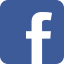
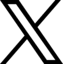
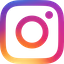
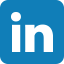
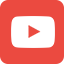

In [22]:
page_content1 = loader.load().pop().page_content
page_content1


In [26]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://careers.nike.com/lead-software-engineer-unreal-engine-itc/job/R-49727")

page_content = loader.load().pop().page_content
page_content


"\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLead Software Engineer - Unreal Engine, ITC\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSkip to main content\nOpen Virtual Assistant\n\n\n\n\n\n\n\n\n\n\nHome\n\n\nCareer Areas\n\n\nTotal Rewards\n\n\nLife@Nike\n\n\nPurpose\n\n\n\n\n\n\n\n\n\n\nLanguage\n\n\n\n\n\nSelect a Language\n\n  Deutsch  \n  English  \n  Español (España)  \n  Español (América Latina)  \n  Français  \n  Italiano  \n  Nederlands  \n  Polski  \n  Tiếng Việt  \n  Türkçe  \n  简体中文  \n  繁體中文  \n  עִברִית  \n  한국어  \n  日本語  \n\n\n\n\n\n\n\n\nCareers\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nClose Menu\n\n\n\n\n\n\n\nCareers\n\n\n\n\n\n\nChat\n\n\n\n\n\n\n                                Home\n                            \n\n\n\n                                Career Areas\n                            \n\n\n\n                                Total Rewards\n                            \n\n\n\n                                Life@Nike\n         

# Prompt template and chaining (pasing to llm )

In [17]:
from langchain_core.prompts import PromptTemplate
prompt_extract = PromptTemplate.from_template(
        """
        ### SCRAPED TEXT FROM WEBSITE
        {page_data}
        ### INSTRUCTION
        The scraped test is from the carrer's page of website.
        Your job is to extract the job posting and return them in JSON format contain the 
        following keys : 'company','role','experience','skills',and 'description'.
        Only return the valid JSON.
        ### VALID JSON (NO PREAMBLE):
        """
)

In [24]:
chain_extract = prompt_extract | llm
response = chain_extract.invoke(input={'page_data':page_content})

In [25]:
print(response.content)

```
{
  "company": "NIKE, Inc.",
  "role": "Lead Software Engineer - Unreal Engine, ITC",
  "experience": "8+ years of professional experience in 3D pipeline development and tool creation",
  "skills": [
    "C++",
    "Unreal Engine framework",
    "3D graphics and rendering techniques",
    "software development best practices",
    "version control systems",
    "CI/CD pipeline automation",
    "testing methodologies"
  ],
  "description": "We are seeking a motivated Software Engineer with a passion for Unreal Engine to help us build the next generation of our configurator and product visualization initiatives. As a Lead Software Engineer with Unreal Engine expertise, you will play a crucial role in driving the technical vision and strategy for our configurator and product visualization initiatives."
}
```


In [27]:
type(response.content)

str

converting str to Json to store in Chromadb for easy use in further retriveals 

In [34]:
from langchain_core.output_parsers import JsonOutputParser

json_parser = JsonOutputParser()
json_response = json_parser.parse(response.content)
json_response

{'company': 'NIKE, Inc.',
 'role': 'Lead Software Engineer - Unreal Engine, ITC',
 'experience': '8+ years of professional experience in 3D pipeline development and tool creation',
 'skills': ['C++',
  'Unreal Engine framework',
  '3D graphics and rendering techniques',
  'software development best practices',
  'version control systems',
  'CI/CD pipeline automation',
  'testing methodologies'],
 'description': 'We are seeking a motivated Software Engineer with a passion for Unreal Engine to help us build the next generation of our configurator and product visualization initiatives. As a Lead Software Engineer with Unreal Engine expertise, you will play a crucial role in driving the technical vision and strategy for our configurator and product visualization initiatives.'}

In [35]:
type(json_response)

dict

Adding Local portfolio file to Chromadb 

In [45]:
import pandas as pd
df = pd.read_csv("C:\\Users\\prave\\OneDrive\\Desktop\\projects\\Cold_email_generator\\portfolio.csv")
df

,Techstack,portfolio
0,"React,Node.js, MongoDB",https://example.com/person1/react-portfolio
1,"Angular, dotNet, SQL server","https://example.com/person2/Angular, dotNet, S..."
2,"Vue.js, Ruby on Rails, PostgreSQL","https://example.com/person3/Vue.js, Ruby on Ra..."
3,"Python, Django, MySQL","https://example.com/person4/Python, Django, My..."
4,"Java, Spring Boot, Oracle","https://example.com/person5/Java, Spring Boot,..."
5,"Flutter, Firebase, GraphQL","https://example.com/person6/Flutter, Firebase,..."
6,"WordPress, PHP,MySQL","https://example.com/person7/reacWordPress, PHP..."
7,"Magento,PHP, MySQL","https://example.com/person8/Magento,PHP, MySQL..."
8,"React,Node.js, MongoDB","https://example.com/person9/React,Node.js, Mon..."
9,"iOS, Swift, Core Data","https://example.com/person10/iOS, Swift, Core ..."


In [47]:
import chromadb
import uuid

client = chromadb.PersistentClient('vectorstore')   # store the data in disk
collection = client.get_or_create_collection(name="portfolio")

if not collection.count():
    for _,row in df.iterrows():  
        collection.upsert(documents=row["Techstack"],               #upsert avoids duplicate values             
                            metadatas = {"links":row["portfolio"]},
                            ids = [str(uuid.uuid4())])
        

In [73]:
print(collection.get())

{'ids': ['06e14e97-cce1-45db-b134-58691d54acaa', '25399f82-1436-4d5d-b383-54fc32725700', '58806fcd-534a-4287-839a-17099514027a', '7e038cf4-b85a-40a1-a19b-7babe853f65e', '99a24121-7c18-4709-8663-65f5b04ed3e3', 'bd27dacf-e148-493c-99f3-f323613a4051', 'd4a2305a-d2f3-416c-a4c3-6e5895d298a1', 'd8fedfab-c064-4185-9009-cdc4df58769f', 'df38827e-aaf9-405d-a4a5-4698eed96ce3', 'f643d0d8-4175-4e5b-8602-7a65b359e93e', 'fdbaf9c7-c0d6-4f4a-a39e-40d13738e296'], 'embeddings': None, 'metadatas': [{'links': 'https://example.com/person5/Java, Spring Boot, Oracle -portfolio'}, {'links': 'https://example.com/person6/Flutter, Firebase, GraphQL-portfolio'}, {'links': 'https://example.com/person11/Androd, Java, Room Persistence-portfolio'}, {'links': 'https://example.com/person10/iOS, Swift, Core Data-portfolio'}, {'links': 'https://example.com/person8/Magento,PHP, MySQL-portfolio'}, {'links': 'https://example.com/person9/React,Node.js, MongoDB-portfolio'}, {'links': 'https://example.com/person1/react-portfoli

In [77]:
links = collection.query(query_texts=["Experince in React"],n_results =2)
links

{'ids': [['bd27dacf-e148-493c-99f3-f323613a4051',
   'd4a2305a-d2f3-416c-a4c3-6e5895d298a1']],
 'distances': [[1.1289199100188108, 1.1289199100188108]],
 'metadatas': [[{'links': 'https://example.com/person9/React,Node.js, MongoDB-portfolio'},
   {'links': 'https://example.com/person1/react-portfolio'}]],
 'embeddings': None,
 'documents': [['React,Node.js, MongoDB', 'React,Node.js, MongoDB']],
 'uris': None,
 'data': None}

In [79]:
links = collection.query(query_texts=["Experince in React","Experince in Python"],n_results =2).get("metadatas")
links

[[{'links': 'https://example.com/person9/React,Node.js, MongoDB-portfolio'},
  {'links': 'https://example.com/person1/react-portfolio'}],
 [{'links': 'https://example.com/person4/Python, Django, MySQL-portfolio'},
  {'links': 'https://example.com/person8/Magento,PHP, MySQL-portfolio'}]]

Testing job skills with collection db

In [81]:
job = json_response

In [85]:
job["skills"]

['C++',
 'Unreal Engine framework',
 '3D graphics and rendering techniques',
 'software development best practices',
 'version control systems',
 'CI/CD pipeline automation',
 'testing methodologies']

In [82]:
links = collection.query(
        query_texts=job['skills'],
        n_results = 2
).get("metadatas",[])
links

[[{'links': 'https://example.com/person11/Androd, Java, Room Persistence-portfolio'},
  {'links': 'https://example.com/person8/Magento,PHP, MySQL-portfolio'}],
 [{'links': 'https://example.com/person9/React,Node.js, MongoDB-portfolio'},
  {'links': 'https://example.com/person1/react-portfolio'}],
 [{'links': 'https://example.com/person7/reacWordPress, PHP,MySQLt-portfolio'},
  {'links': 'https://example.com/person8/Magento,PHP, MySQL-portfolio'}],
 [{'links': 'https://example.com/person8/Magento,PHP, MySQL-portfolio'},
  {'links': 'https://example.com/person5/Java, Spring Boot, Oracle -portfolio'}],
 [{'links': 'https://example.com/person11/Androd, Java, Room Persistence-portfolio'},
  {'links': 'https://example.com/person7/reacWordPress, PHP,MySQLt-portfolio'}],
 [{'links': 'https://example.com/person8/Magento,PHP, MySQL-portfolio'},
  {'links': 'https://example.com/person7/reacWordPress, PHP,MySQLt-portfolio'}],
 [{'links': 'https://example.com/person11/Androd, Java, Room Persistence

Combining promp Template and llm along with db data

In [91]:
prompt_email = PromptTemplate.from_template(
    
    """
    ### JOB DESCRIPTION
    {job_description}
    Your are praveen, Operation Manager and business development executive at PraAI. PraAI is an AI and Software Consulting
    company with the seamless integration of business process throug autommated tools.
    Over our experience, we have empowered numerous enterprise with tailored solutions, fostering scalability,
    process oprimization, cost reduction, and heightend overall efficiency.
    YOur job is to write a cold email to the client regarding the job mentioned above describing the capability of PraAI.
    in fulfulling their needs.
    Also add the most relevant one form the following links to showcase PraAI's portfolios {link_list}.
    Remeber you are a praveen, OP & BDE at PraAI.
    Do not provide preamble 
    ### EMAIL (NO PREAMBEL):
    """

)

chain_email = prompt_email | llm
response = chain_email.invoke({"job_description": str(job),"link_list": links})
print(response.content)

Subject: Expert Software Solutions for NIKE's Configurator and Product Visualization Initiatives

Dear Hiring Manager,

I came across the job posting for a Lead Software Engineer - Unreal Engine, ITC at NIKE, Inc. and was impressed by the company's innovative approach to product visualization. As the Operation Manager and Business Development Executive at PraAI, I believe our team can provide the necessary expertise to drive the technical vision and strategy for your configurator and product visualization initiatives.

With 8+ years of experience in 3D pipeline development and tool creation, our team possesses the required skills to excel in this role, including C++, Unreal Engine framework, 3D graphics and rendering techniques, software development best practices, version control systems, CI/CD pipeline automation, and testing methodologies. Our expertise in software development, combined with our passion for innovation, makes us an ideal fit for this position.

I'd like to showcase o